In [1]:
!pip install -q fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.2 MB/s eta 0:00:00:00:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### Выгрузка данных

In [3]:
# данные о реальном спросе
real_demand = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/real_demand_data.parquet', engine='fastparquet')

# данные о стоках
stock = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/stock_data.parquet', engine='fastparquet')

# данные о продажах (реальность)
gmv = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/gmv_dataset.parquet', engine='fastparquet')

### Типы рядов

Наиболее фундаментальным и широко применяемым подходом в области управления запасами является классификация SBC (Syntetos, Boylan, Croston), предложенная в 2005 году. Она базируется на расчёте двух ключевых параметров временного ряда: 

1. **ADI (Average Demand Interval)**: Средний интервал между возникновениями спроса, характеризующий временную регулярность появления заказов, т.е. как часто возникают продажи (спрос).  
   $$ADI = \frac{\sum_{i=1}^{n} t_i}{n},$$  
   где $t_i$ — интервал между $(i-1)$-й и $i$-й ненулевой продажей, $n$ — количество таких интервалов.

2. **CV² (Squared Coefficient of Variation)**: Квадрат коэффициента вариации объемов спроса, измеряющий изменчивость величины заказа в моменты его возникновения. Показывает регулярность объемов спроса, когда он возникает.  
   $$CV^2 = \left( \frac{\sigma}{\mu} \right)^2,$$  
   где $\sigma$ — стандартное отклонение ненулевого спроса, $\mu$ — среднее значение ненулевого спроса.



На основе пороговых значений (ADI = 1.32 и CV² = 0.49) выделяются четыре типа паттернов спроса:

1. **Гладкий (Smooth)**. ADI < 1.32 и CV² < 0.49. Характеризуется регулярными продажами и низкой вариативностью объема. Это наиболее предсказуемый тип, для которого эффективны стандартные регрессионные модели и экспоненциальное сглаживание.
2. **Прерывистый (Intermittent)**. ADI ≥ 1.32 и CV² < 0.49. Продажи происходят редко (большие паузы), но объемы заказов относительно стабильны. Этот тип обычно преобладает в «длинном хвосте» ассортимента маркетплейсов.
3. **Нерегулярный (Erratic)**. ADI < 1.32 и CV² ≥ 0.49. Продажи происходят почти постоянно, но их объемы крайне изменчивы, что часто связано с маркетинговыми акциями или внешними шоками.
4. **Комковатый (Lumpy)**. ADI ≥ 1.32 и CV² ≥ 0.49. Самый сложный паттерн, сочетающий редкие продажи с огромной вариативностью объемов. Для него характерна максимальная неопределенность.

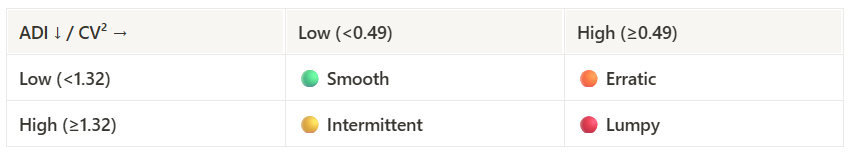

### Функция определяющая тип ряда

In [5]:
def classify_demand_pattern(ts, adi_threshold=1.32, cv2_threshold=0.49):
    """
    Классифицирует тип спроса по методологии Syntetos/Boylan.

    Параметры:
    ----------
    ts : array-like
        Временной ряд (список или массив чисел).
    adi_threshold : float, default=1.32
        Порог ADI для разделения частого/редкого спроса.
    cv2_threshold : float, default=0.49
        Порог CV² для разделения стабильного/нестабильного объёма.

    Возвращает:
    -------
    str
        Один из пяти типов:
        - 'retired'     : все значения ряда нулевые или ряд пуст
        - 'smooth'      : гладкий (частый, стабильный объём)
        - 'erratic'     : нестабильный (частый, нестабильный объём)
        - 'intermittent': прерывистый (редкий, стабильный объём)
        - 'lumpy'       : комковатый (редкий, нестабильный объём)
    """
    # Преобразуем в numpy-массив для удобства
    ts = np.asarray(ts)
    
    # Проверка на retired: пустой ряд или все значения равны нулю
    if ts.size == 0 or np.all(ts == 0):
        return 'retired'
    
    # Рассчитываем общую длину ряда
    T = len(ts)
    
    # Выделяем ненулевые значения
    non_zero = ts[ts != 0]
    N = len(non_zero)
    
    # 1. Расчёт ADI (Average Demand Interval = общее кол-во элементов ряда / кол-во ненулевых элементов ряда)
    ADI = T / N
    
    # 2. Расчёт CV² (Coefficient of Variation squared) для ненулевых значений
    if N <= 1:
        CV2 = 0.0  # Вариация отсутствует
    else:
        mean_demand = np.mean(non_zero)
        std_demand = np.std(non_zero, ddof=1)
        if mean_demand == 0:
            CV2 = 0.0
        else:
            CV2 = (std_demand / mean_demand) ** 2
    
    is_high_adi = ADI >= adi_threshold
    is_high_cv2 = CV2 >= cv2_threshold
    
    if not is_high_adi and not is_high_cv2:
        return 'smooth'
    elif not is_high_adi and is_high_cv2:
        return 'erratic'
    elif is_high_adi and not is_high_cv2:
        return 'intermittent'
    else:
        return 'lumpy'

### Определяем тип ряда (intermittent / not_intermittent / retired)

In [6]:
sku_list = list(set(real_demand['SKU_id']))
real_demand = real_demand.sort_values("date")

ts_dict = {}

for i in sku_list:

    # Фильтруемся по текущей SKU, забираем список последовательных значений спроса данной SKU
    demand_list = list(real_demand.query("SKU_id == @i")['real_demand'])

    # оставляем последние 90 (или меньше) дней наблюдений
    # логика - есть случаи, когда SKU долгое время продавалась плохо и медленно на старте (много нулевых значений), а потом разгонялась
    # такие ряды не intermittent, это просто новинки, которые на старте набирали популярность / отзывы
    demand_list = demand_list[-90:] 


    # Определяем тип ряда для каждой SKU
    ts_dict[i] = classify_demand_pattern(demand_list)

In [7]:
pd.set_option('display.float_format', '{:,.2f}'.format)

ts_dict_df = pd.DataFrame(ts_dict.values(), ts_dict.keys()).reset_index()
ts_dict_df = ts_dict_df.rename(columns = {'index': 'SKU_id', 0: 'ts_type'})

sku_gmv_df = real_demand.groupby(['SKU_id']).agg({'real_demand': 'sum'}).reset_index()

result = pd.merge(ts_dict_df, sku_gmv_df, how = 'left', on = 'SKU_id')

summary = result.groupby(['ts_type']).agg({'SKU_id':'count', 'real_demand': 'sum'}).reset_index()
total_gmv = summary['real_demand'].sum()

summary['share_%'] = (summary['real_demand'] / total_gmv * 100).round(2)

summary

,ts_type,SKU_id,real_demand,share_%
0,erratic,841,"2,203,823.00",19.86
1,intermittent,8355,"1,537,499.00",13.86
2,lumpy,3160,"1,091,176.00",9.84
3,retired,1307,"149,733.00",1.35
4,smooth,1808,"6,111,993.00",55.09


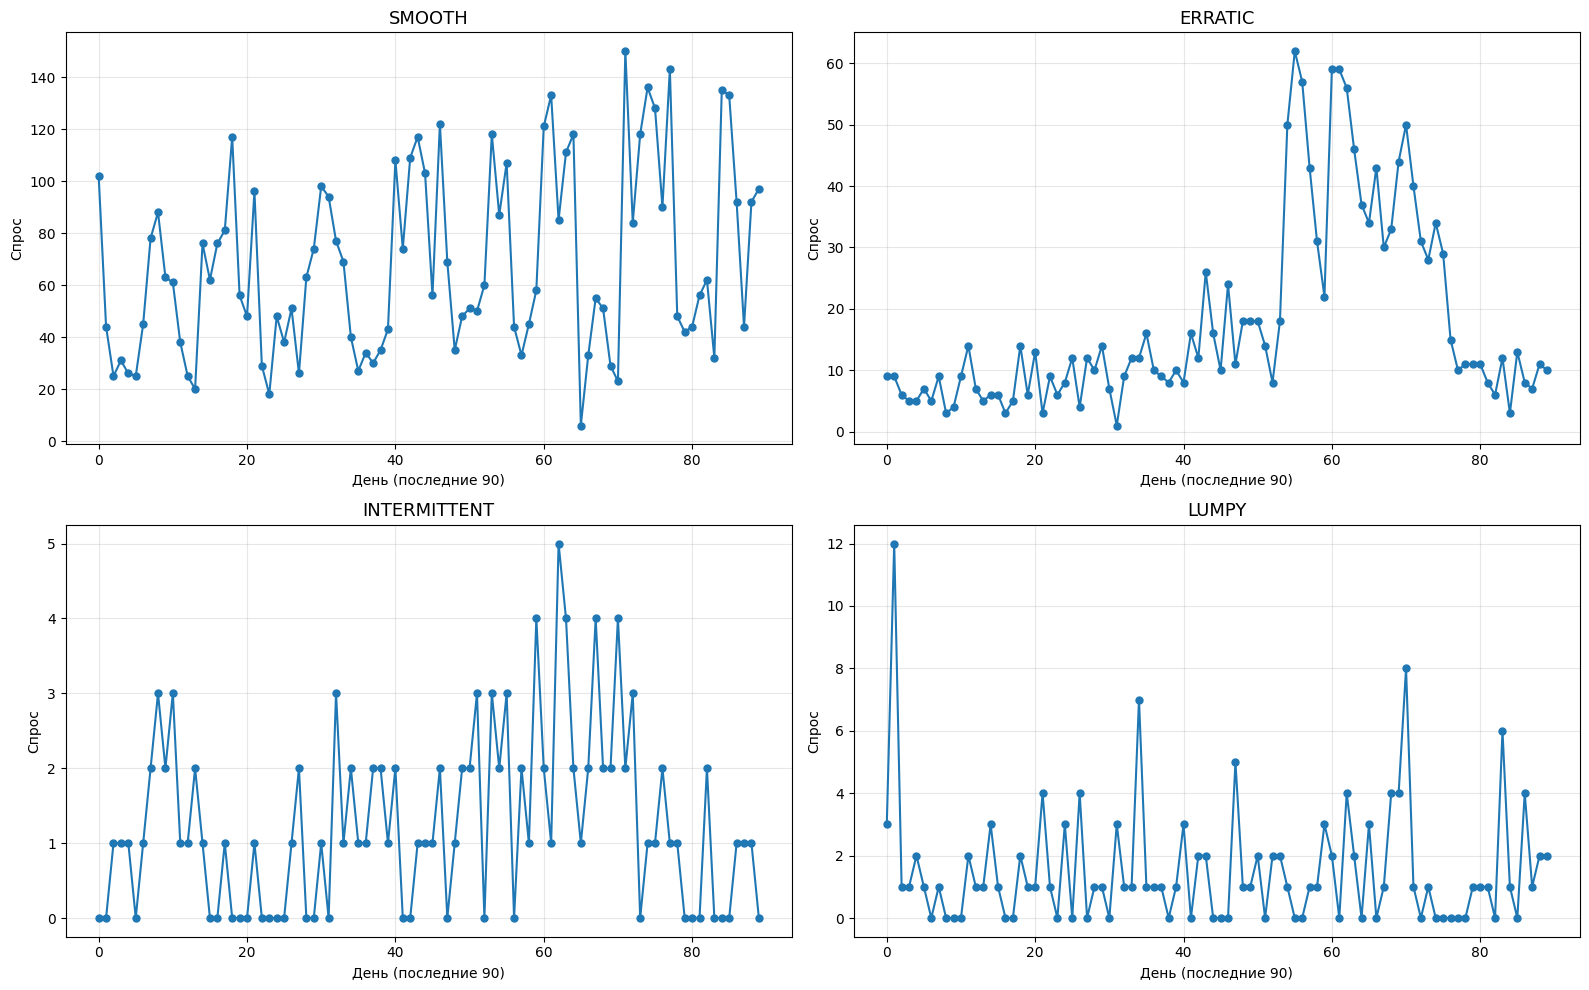

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()  

for idx, (pattern_type, sku) in enumerate(sku_examples.items()):
    ax = axes[idx]
    
    demand_series = (
        real_demand
        .query("SKU_id == @sku")
        .sort_values("date")['real_demand']
        .values
    )
    demand_series = demand_series[-90:]
    
    ax.plot(demand_series, marker='o', linestyle='-', markersize=5, linewidth=1.5)
    ax.set_title(f"{pattern_type.upper()}", fontsize=13)
    ax.set_xlabel("День (последние 90)")
    ax.set_ylabel("Спрос")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()